In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform

import torch
import torch.nn as nn
import torch.optim as optim

import sklearn
from sklearn.datasets import load_digits, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

# 데이터를 가져오는 모듈
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, Dataset, DataLoader

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

sklearn.set_config(display="text")

# Fashion-MNIST
- 28x28 크기의 흑백 이미지 60,000장으로 구성된 10개 클래스의 의류 데이터셋으로, PyTorch의 torchvision 패키지에서 제공하는 대표적인 비전 학습용 데이터셋입니다.
  숫자 데이터에 비해 사물의 형태와 질감이 다양하여 데이터 증강 기법을 적용했을 때 모델의 일반화 성능 변화를 관찰하기에 적합합니다.

### Fashion-MNIST 클래스 라벨 설명 (Class Labels)
| 라벨 (Label) | 클래스명 (Class Name) | 설명 (Description) |
| --- | --- | --- |
| 0 | T-shirt/top | 티셔츠 / 상의 |
| 1 | Trouser | 바지 |
| 2 | Pullover | 풀오버 (스웨터) |
| 3 | Dress | 드레스 / 원피스 |
| 4 | Coat | 코트 |
| 5 | Sandal | 샌들 |
| 6 | Shirt | 셔츠 |
| 7 | Sneaker | 스니커즈 / 운동화 |
| 8 | Bag | 가방 |
| 9 | Ankle boot | 앵클부츠 |

In [2]:
base_path = r"C:\kdt_0900_osg\ml\resource\dataset"

In [3]:
train_data = datasets.FashionMNIST(root=base_path, train=True, download=True)
test_data = datasets.FashionMNIST(root=base_path, train=False, download=True)

100%|██████████| 26.4M/26.4M [00:06<00:00, 4.25MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 105kB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 1.87MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]


In [4]:
print(train_data.data.shape)
print(test_data.data.shape)

torch.Size([60000, 28, 28])
torch.Size([10000, 28, 28])


In [5]:
X_train = train_data.data
y_train = train_data.targets

X_test = test_data.data
y_test = test_data.targets

In [6]:
print(X_train[1])

tensor([[  0,   0,   0,   0,   0,   1,   0,   0,   0,   0,  41, 188, 103,  54,
          48,  43,  87, 168, 133,  16,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   1,   0,   0,   0,  49, 136, 219, 216, 228, 236, 255,
         255, 255, 255, 217, 215, 254, 231, 160,  45,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,  14, 176, 222, 224, 212, 203, 198, 196, 200,
         215, 204, 202, 201, 201, 201, 209, 218, 224, 164,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0, 188, 219, 200, 198, 202, 198, 199, 199, 201,
         196, 198, 198, 200, 200, 200, 200, 201, 200, 225,  41,   0,   0,   0],
        [  0,   0,   0,   0,  51, 219, 199, 203, 203, 212, 238, 248, 250, 245,
         249, 246, 247, 252, 248, 235, 207, 203, 203, 222, 140,   0,   0,   0],
        [  0,   0,   0,   0, 116, 226, 206, 204, 207, 204, 101,  75,  47,  73,
          48,  50,  45,  51,  63, 113, 222, 202, 206, 220, 224,   0,   0,   0],
        [  0,   0,   0,   0, 200, 222, 209, 20

In [7]:
print(y_train[:1])
print(type(y_train[:1].item()))

tensor([9])
<class 'int'>


In [18]:
classes_dict = dict(enumerate(train_data.classes))
classes_dict

{0: 'T-shirt/top',
 1: 'Trouser',
 2: 'Pullover',
 3: 'Dress',
 4: 'Coat',
 5: 'Sandal',
 6: 'Shirt',
 7: 'Sneaker',
 8: 'Bag',
 9: 'Ankle boot'}

In [19]:
print(X_train[1].size())

torch.Size([28, 28])


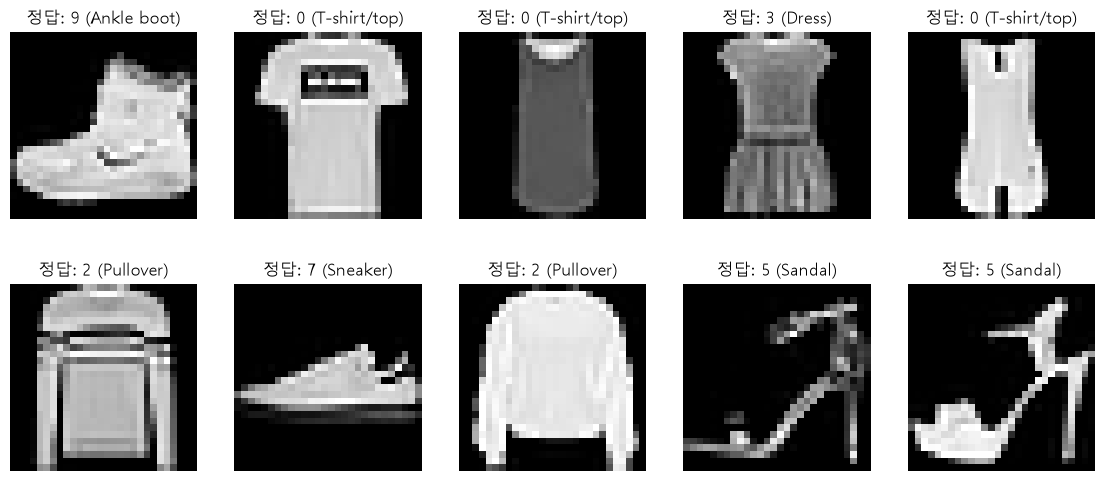

In [20]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(14, 6))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_train[i], cmap="gray")
    ax.axis("off")
    key = y_train[i].item()
    ax.set_title(f"정답: {key} ({classes_dict[key]})")
    
plt.show()

# 스케일링(정규화)

In [21]:
X_train_tensor = X_train / 255.0
y_train_tensor = y_train.long()

X_test_tensor = X_test / 255.0
y_test_tensor = y_test.long()

In [22]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [24]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [26]:
imgs, labels = next(iter(train_loader))

print(imgs.shape, labels.shape)

torch.Size([64, 28, 28]) torch.Size([64])


# 모델 준비

In [27]:
model = nn.Sequential(
    nn.Flatten(), # 28 x 28 -> 784
    nn.Linear(784, 10)
)

In [28]:
# 손실함수
criterion = nn.CrossEntropyLoss()
optimazier = optim.Adam(model.parameters(), lr=0.01)

In [30]:
epochs = 50

for epoch in range(epochs):
    model.train()

    sum_losses = 0.0
    sum_accs = 0.0

    for X_batch, y_batch in train_loader:
        optimazier.zero_grad() # 기울기 초기화
        y_pred = model(X_batch) # 순전파
        loss = criterion(y_pred, y_batch) # 손실
        loss.backward() # 역전파
        optimazier.step() # 기울기 업데이트

        sum_losses += loss.item()
        y_pred_index = y_pred.argmax(dim=1)
        acc = (y_batch == y_pred_index). float().mean().item() * 100
        sum_accs += acc

    avg_train_loss = sum_losses / len(train_loader)
    avg_train_acc = sum_accs / len(train_loader)

    print(f"Epoch: {epoch + 1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}%")

Epoch: 1/50 | Train Loss: 0.5612 | Train Acc: 81.16%
Epoch: 2/50 | Train Loss: 0.4884 | Train Acc: 83.84%
Epoch: 3/50 | Train Loss: 0.4947 | Train Acc: 83.83%
Epoch: 4/50 | Train Loss: 0.4834 | Train Acc: 84.17%
Epoch: 5/50 | Train Loss: 0.4755 | Train Acc: 84.52%
Epoch: 6/50 | Train Loss: 0.4715 | Train Acc: 84.42%
Epoch: 7/50 | Train Loss: 0.4669 | Train Acc: 84.56%
Epoch: 8/50 | Train Loss: 0.4569 | Train Acc: 84.83%
Epoch: 9/50 | Train Loss: 0.4672 | Train Acc: 84.73%
Epoch: 10/50 | Train Loss: 0.4682 | Train Acc: 84.65%
Epoch: 11/50 | Train Loss: 0.4722 | Train Acc: 84.71%
Epoch: 12/50 | Train Loss: 0.4612 | Train Acc: 84.91%
Epoch: 13/50 | Train Loss: 0.4627 | Train Acc: 84.87%
Epoch: 14/50 | Train Loss: 0.4604 | Train Acc: 84.87%
Epoch: 15/50 | Train Loss: 0.4580 | Train Acc: 85.10%
Epoch: 16/50 | Train Loss: 0.4580 | Train Acc: 84.93%
Epoch: 17/50 | Train Loss: 0.4539 | Train Acc: 85.09%
Epoch: 18/50 | Train Loss: 0.4577 | Train Acc: 84.98%
Epoch: 19/50 | Train Loss: 0.4540 | T

In [37]:
model.eval()

test_loss = 0.0
test_acc = 0.0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_test_pred = model(X_batch)
        loss = criterion(y_test_pred, y_batch)
        test_loss += loss.item()

        y_test_index = y_test_pred.argmax(dim=1)
        acc = (y_batch == y_test_index).float().mean().item() * 100
        test_acc += acc
   
avg_test_loss = test_loss / len(test_loader)        
avg_test_acc = test_acc / len(test_loader)        

print(f"최종 Test 결과 | Loss: {avg_test_loss:.4f} | Accuracy: {avg_test_acc:.2f}%")

최종 Test 결과 | Loss: 0.5743 | Accuracy: 83.01%


In [32]:
X_sample, y_sample = next(iter(test_loader))

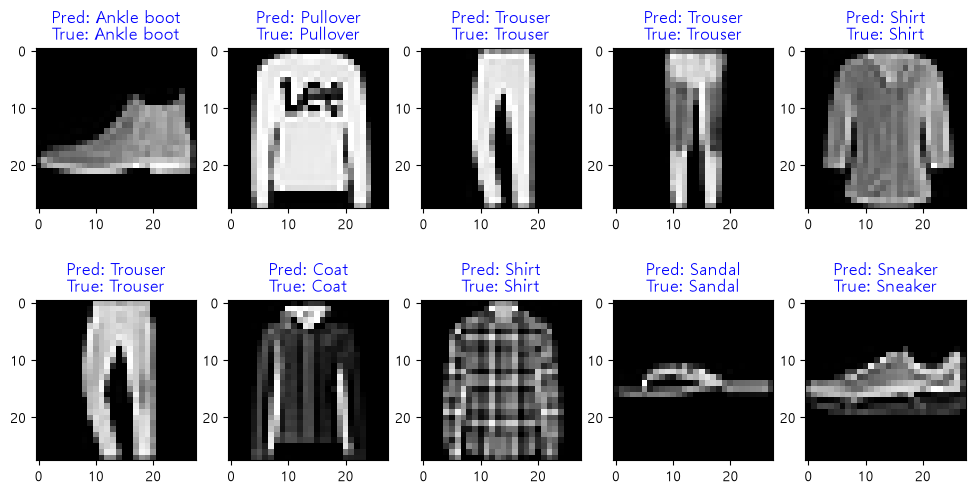

In [44]:
model.eval()

with torch.no_grad():
    sample_prads = model(X_sample)
    pred_indexes = sample_prads.argmax(dim=1)

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = X_sample[i]
    pred_label = classes_dict[pred_indexes[i].item()]
    true_label = classes_dict[y_sample[i].item()]
    color = "blue" if pred_label == true_label else "red"

    plt.imshow(img, cmap="gray")
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)



plt.show()

# 데이터 증강(Data Augmentation)
- 학습 데이터를 인위적으로 변환하여 데이터셋의 다양성을 높이고 모델의 일반화 성능을 향상시키는 기법 입니다. 회전, 크기 조정, 반전, 블러링, 밝기 조정 등 다양한 변환을 적용하여 원본 데이터로부터 새로운 데이터를 생성합니다. 이를 통해 데이터 부족 문제를 완화하고 모델이 특정 패턴에 과적합되지 않도록 도와줍니다. 특히, 이미지나 음성 데이터와 같이 특징이 직관적인 데이터에서 효 과적으로 활용되며, 증강된 데이터는 모델이 예측 대상의 다양한 변형에 대해 강하게 학습할 수 있도록 돕습니다.
1. **단, 1000 -> 10000 처럼 변화하는 데이터를 증가시키는 것이 아니다.
2. DataLoader -> Batch -> 1개 배치를 꺼내올 때 랜덤하게 데이터 증강 후 학습 -> 따라서 데이터의 개수가 늘어나는 것이 아니다.

In [45]:
X_train = train_data.data
y_train = train_data.targets

X_test = test_data.data
y_test = test_data.targets

In [46]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

torch.Size([60000, 28, 28]) torch.Size([60000]) torch.Size([10000, 28, 28]) torch.Size([10000])


## 스케일링(정규화)

In [47]:
X_train_tensor = X_train / 255.0
y_train_tensor = y_train.long()

X_test_tensor = X_test / 255.0
y_test_tensor = y_test.long()

In [48]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

## 데이터 증강 기법
### transforms.Compose()
- 여러 데이터 변환 작업을 순차적으로 적용할 수 있도록 해줍니다. 이미지 데이터 전처리와 증강 과정에서 자주 사용되며, 각 변환을 하나의 리스트로 묶어 실행합니다.
  
| 분류 | 메서드 | 주요 파라미터 / 설정 예시 | 설명 및 특징 |
| :--- | :--- | :--- | :--- |
| **반전 (Flip)** | `RandomHorizontalFlip` | `p=0.5` | 지정한 확률(`p`)로 이미지를 좌우로 뒤집음 |
| | `RandomVerticalFlip` | `p=0.5` | 지정한 확률(`p`)로 이미지를 상하로 뒤집음 |
| **기하학 변형** | `RandomRotation` | `degrees=10` 또는 `(-10, 10)` | 지정한 각도 범위 내에서 이미지를 무작위로 회전 |
| | `RandomAffine` | `degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=5` | 회전, 평행이동(`translate`), 확대/축소(`scale`), 전단 변형(`shear`)을 한 번에 적용 |
| | `RandomCrop` | `size=(28, 28), padding=2` | 이미지 주변에 패딩을 더한 뒤 지정한 크기로 무작위로 잘라냄 (위치 변화 효과) |
| | `CenterCrop` | `size=(24, 24)` | 이미지의 중앙 부분을 지정한 크기만큼 잘라냄 |
| | `Resize` | `size=(32, 32)` | 이미지를 지정한 크기로 리사이징 |
| **색상/명암** | `ColorJitter` | `brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1` | 밝기(`brightness`), 대비(`contrast`), 채도(`saturation`), 색상(`hue`)을 무작위로 변경 |
| | `RandomGrayscale` | `p=0.1` | 지정한 확률(`p`)로 이미지를 흑백(Grayscale)으로 변환 |
| **지우기 (Eraser)** | `RandomErasing` | `p=0.5, scale=(0.02, 0.2)` | 이미지의 일부 노이즈 구역을 무작위로 가림 (반드시 `ToTensor()` 뒤에 위치) |
| **필수 변환** | `ToTensor` | 없음 | PIL Image 또는 NumPy 배열($0 \sim 255$)을 PyTorch FloatTensor($0.0 \sim 1.0$)로 자동 변환 |
| | `Normalize` | `mean=[0.5], std=[0.5]` | 각 채널의 평균(`mean`)과 표준편차(`std`)를 이용해 $[-1.0, 1.0]$ 영역 등으로 정규화 |

In [51]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), # 50% 확률로 좌우 반전
    transforms.RandomRotation(degrees=10), # -10 ~ 10도까지 무작위 회전
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05), # 가로, 세로, 5% 범위 내에서 이미지 자신이 이동
        scale=(0.95, 1.05), # 95 ~ 105% 범위 내에서 축소 및 확대
        shear=5 # 5도 비틀기
    ),
    transforms.RandomErasing(p=0.02, scale=(0.02, 0.1)) # 20%의 확률로 이미지를 일부씩 가리는 노이즈 생성
])

test_transform = transforms.Compose([])

In [60]:
class AugmentDataset(Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform

    # 오버라이딩
    def __len__(self):
        return len(self.dataset)

    # 오버라이딩
    def __getitem__(self, idx):
        X, y = self.dataset[idx]
        # 그레이 스케일만 차원을 추가 (1, 28, 28)
        # 컬러라면 RGB 레이어가 있으므로 추가할 필요가 없다. (3, 28, 28)
        X = X.view(28, 28).unsqueeze(0)
        X = self.transform(X)
        return X.flatten(), y

In [61]:
train_agu_dataset = AugmentDataset(train_dataset, train_transform)
test_agu_dataset = AugmentDataset(test_dataset, test_transform)

In [62]:
train_loader = DataLoader(train_agu_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_agu_dataset, batch_size=64)

In [63]:
imgs, labels = next(iter(train_loader))

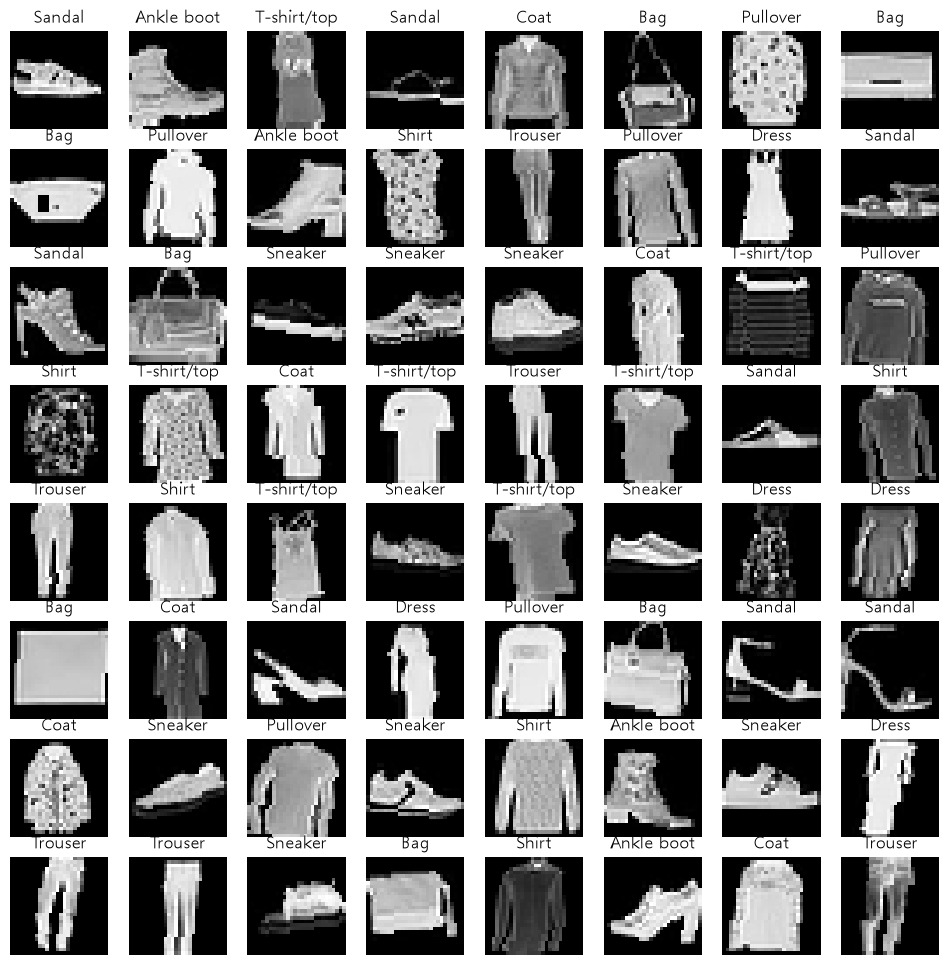

In [65]:
plt.figure(figsize=(12, 12))
for i in range(len(imgs)):
    plt.subplot(8, 8, i + 1)
    img = imgs[i].view(28, 28).numpy()

    label_idx = labels[i].item()
    class_name = classes_dict[label_idx]

    plt.imshow(img, cmap="gray")
    plt.title(class_name)
    plt.axis("off")

plt.show()

## 모델 준비

In [66]:
model = nn.Sequential(
    nn.Linear(28 * 28, 10)
)

In [67]:
criterion = nn.CrossEntropyLoss()
optimazier = optim.Adam(model.parameters(), lr=0.001)

In [68]:
epochs = 50

for epoch in range(epochs):
    model.train()

    sum_losses = 0.0
    sum_accs = 0.0

    for X_batch, y_batch in train_loader:
        optimazier.zero_grad() # 기울기 초기화
        y_pred = model(X_batch) # 순전파
        loss = criterion(y_pred, y_batch) # 손실
        loss.backward() # 역전파
        optimazier.step() # 기울기 업데이트

        sum_losses += loss.item()
        y_pred_index = y_pred.argmax(dim=1)
        acc = (y_batch == y_pred_index). float().mean().item() * 100
        sum_accs += acc

    avg_train_loss = sum_losses / len(train_loader)
    avg_train_acc = sum_accs / len(train_loader)

    print(f"Epoch: {epoch + 1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}%")

Epoch: 1/50 | Train Loss: 0.9577 | Train Acc: 66.80%
Epoch: 2/50 | Train Loss: 0.8062 | Train Acc: 71.84%
Epoch: 3/50 | Train Loss: 0.7748 | Train Acc: 73.18%
Epoch: 4/50 | Train Loss: 0.7609 | Train Acc: 73.41%
Epoch: 5/50 | Train Loss: 0.7503 | Train Acc: 73.87%


KeyboardInterrupt: 

In [69]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.mps.is_available():
    device = torch.device("mps")
elif torch.xpu.is_available():
    device = torch.device("xpu")
else:
    device = torch.device("cpu")

print(f"현재 선택된 장치: {device}")

현재 선택된 장치: cpu


In [72]:
model = model.to(device)
optimazier = optim.Adam(model.parameters(), lr=0.001)

In [73]:
epochs = 50

for epoch in range(epochs):
    model.train()

    sum_losses = 0.0
    sum_accs = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimazier.zero_grad() # 기울기 초기화
        y_pred = model(X_batch) # 순전파
        loss = criterion(y_pred, y_batch) # 손실
        loss.backward() # 역전파
        optimazier.step() # 기울기 업데이트

        sum_losses += loss.item()
        y_pred_index = y_pred.argmax(dim=1)
        acc = (y_batch == y_pred_index).float().mean().item() * 100
        sum_accs += acc

    avg_train_loss = sum_losses / len(train_loader)
    avg_train_acc = sum_accs / len(train_loader)

    print(f"Epoch: {epoch + 1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}%")

Epoch: 1/50 | Train Loss: 0.7301 | Train Acc: 74.39%
Epoch: 2/50 | Train Loss: 0.7291 | Train Acc: 74.41%
Epoch: 3/50 | Train Loss: 0.7301 | Train Acc: 74.43%
Epoch: 4/50 | Train Loss: 0.7233 | Train Acc: 74.58%
Epoch: 5/50 | Train Loss: 0.7269 | Train Acc: 74.55%
Epoch: 6/50 | Train Loss: 0.7281 | Train Acc: 74.53%
Epoch: 7/50 | Train Loss: 0.7251 | Train Acc: 74.46%
Epoch: 8/50 | Train Loss: 0.7228 | Train Acc: 74.44%
Epoch: 9/50 | Train Loss: 0.7228 | Train Acc: 74.38%
Epoch: 10/50 | Train Loss: 0.7209 | Train Acc: 74.42%
Epoch: 11/50 | Train Loss: 0.7222 | Train Acc: 74.54%
Epoch: 12/50 | Train Loss: 0.7205 | Train Acc: 74.72%
Epoch: 13/50 | Train Loss: 0.7207 | Train Acc: 74.76%
Epoch: 14/50 | Train Loss: 0.7167 | Train Acc: 74.69%
Epoch: 15/50 | Train Loss: 0.7208 | Train Acc: 74.67%
Epoch: 16/50 | Train Loss: 0.7178 | Train Acc: 74.76%
Epoch: 17/50 | Train Loss: 0.7194 | Train Acc: 74.64%
Epoch: 18/50 | Train Loss: 0.7175 | Train Acc: 74.69%
Epoch: 19/50 | Train Loss: 0.7190 | T

KeyboardInterrupt: 